In [1]:
from IPython.display import HTML, Javascript, display

display(HTML("""
<style>
a[href^="http://"],
a[href^="https://"] {
    color: blue !important;
}

/* stil za sve tabele */
table {
    margin-left: auto !important;
    margin-right: auto !important;
    width: auto !important;
    max-width: none !important;
    table-layout: auto !important;
    border-collapse: collapse !important;
    font-family: "Segoe UI", "Calibri", sans-serif !important;
    font-size: 12px !important;
}

th, td {
    padding: 8px 20px !important;
}

/* markdown tabela – zadrži staro ponašanje */
table:not(.dataframe) tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* dataframe – samo pravo zaglavlje */
table.dataframe thead tr:first-child th {
    border-bottom: 2px solid #222 !important;
}

/* index kolona dataframe da ne bude bold */
table.dataframe tbody th {
    font-weight: normal !important;
}

/* linija ispod poslednjeg reda */
tbody tr:last-child td,
tbody tr:last-child th {
    border-bottom: 1px solid #aaa !important;
}

/* caption */
caption,
.table-caption,
p.caption,
div.caption,
figcaption {
    text-align: center !important;
    font-weight: bold !important;
}
</style>
"""))

display(Javascript("""
function promeniTableUTabela() {
    const selectors = [
        "caption",
        ".table-caption",
        "p.caption",
        "div.caption",
        "figcaption",
        ".caption-number"
    ];

    document.querySelectorAll(selectors.join(",")).forEach(function(el) {
        if (el.innerHTML.includes("Table")) {
            el.innerHTML = el.innerHTML.replace(/\\bTable\\b/g, "Tabela");
        }
    });
}

promeniTableUTabela();

/* ako se notebook kasnije rerenderuje */
const observer = new MutationObserver(function() {
    promeniTableUTabela();
});

observer.observe(document.body, {
    childList: true,
    subtree: true
});
"""))

<IPython.core.display.Javascript object>

# Stabla odlučivanja
<br>
Stabla odlučivanja (engl. decision tree) predstavljaju jedan od najčešće korišćenih modela u nadgledanom mašinskom učenju za klasifikaciju i regresiju. Zasniva se na sekvencijalnom donošenju odluka kroz *if/else* pravila, čime se podaci postepeno dele na homogenije grupe i formira interpretabilan model. Ovakav pristup omogućava jednostavnu analizu i primenu u ekonomskim problemima kao što su procena rizika, segmentacija i predikcija.

U ovom delu biće predstavljeni osnovni koncepti stabala odlučivanja, uključujući proces izgradnje stabla, kriterijume grananja i interpretaciju modela. Posebna pažnja biće posvećena primeni u klasifikacionim i regresionim zadacima, kao i praktičnoj implementaciji u Pajton okruženju.

**Ishodi učenja**: Nakon proučavanja ovog poglavlja student će biti u stanju da:
- razume princip rada stabala odlučivanja u okviru nadgledanog učenja;
- objasni proces grananja i formiranja homogenih grupa podataka;
- primeni modele stabala za klasifikaciju i regresiju u ekonomskim problemima;
- interpretira strukturu stabla i značaj atributa u modelu;
- implementira osnovne modele stabala koristeći odgovarajuće Pajton biblioteke.

## Uvod

Naziv *stablo odlučivanja* proistekao je iz njihove strukture, čiji prikaz podseća na oblik stabla. Stablo odlučivanja može se posmatrati kao složena hijerarhijska struktura koja se sastoji od više međusobno povezanih elemenata:
- *korenski čvor* (*engl. root node*) je početni čvor stabla odlučivanja, sadrži ceo početni skup i izvršava prvu podelu podataka,
- *unutrašnji čvorovi* (*engl. internal nodes*) predstavljaju testove grananja u odnosu na odredjenu karakteristiku, i nalaze se između korenskog čvora i listova,
- *listovi* (*engl. leaves*) predstavljaju konačne klase ili predikcije, to su krajnji čvorovi u kojima se grananje stabla završava,
- *grane* (*engl. branches*) predstavljaju moguće vrednosti izabrane karakteristike, pri čemu se primeri razvrstavaju u podskupove u skladu sa tim vrednostima, 
- *atribut odluke* (*eng. decision attribute*) je karakteristika koja se koristi da se postavi kriterijum podele u čvoru.

Korenski čvor predstavlja polaznu tačku stabla, jer sadrži ceo skup podataka i izvršava prvu podelu prema definisanom kriterijumu. Unutrašnji čvorovi predstavljaju tačke daljeg razdvajanja podataka prema vrednostima izabranih atributa. Grane povezuju čvorove i prikazuju ishode odluka, vodeći ka narednom čvoru sa sledećim testom ili ka listu, koji predstavlja krajnji ishod, tj. finalnu klasu ili predikciju. 

Svaki primer kreće od korenskog čvora i, na osnovu vrednosti atributa, prolazi kroz stablo do lista koji određuje njegov ishod. Ovakva struktura omogućava jasan i intuitivan uvid u proces odlučivanja, jer se složeni podaci prevode u niz jednostavnih pravila. Putanja od lista ka korenu daje obrazloženje odluke, pa se model može predstaviti skupom pravila tipa ako–onda (engl. if–then).

U zavisnosti od tipa ciljne promenljive, razlikuju se dve osnovne vrste stabala odlučivanja:
- *Klasifikaciona stabla*, kod kojih je ciljna promenljiva kategorijska i uzima vrednosti iz konačnog skupa. Listovi predstavljaju odgovarajuće klase, dok grane odražavaju niz uslova nad atributima koji vode do određene klasne oznake.
- *Regresiona stabla*, koja se primenjuju kada je ciljna promenljiva neeprekidne prirode. Njihov cilj je predviđanje numeričke vrednosti, koja se najčešće određuje kao prosečna vrednost posmatranja koja pripadaju tom listu.

### Jednostavan primer

Na slici 1. je primer stabla odlučivanja u kome se odluka o odobravanju kredita donosi postepenim grananjem na osnovu kreditne istorije, prihoda i nivoa zaduženosti. 

```{figure} ML_Slike/DrvoStruktura.png
:width: 600px
:align: center

Primer strukture stabla odlučivanja.
```

Svaki list stabla dodeljuje klasu koja je najzastupljenija među trening uzorcima koji su u njega dospeli, dok se novi uzorak, na osnovu vrednosti svojih karakteristika, vodi kroz grane stabla do lista koji predstavlja predikciju njegove klase.

Smanjenje nehomogenosti duž putanje od korena do lista ogleda se u postepenom razdvajanju podataka na sve homogenije podskupove. Ovaj proces, ilustrovan na slici 2, pokazuje kako se svakom narednom podelom povećava čistoća čvorova sve do formiranja listova.

```{figure} ML_Slike/NovaHomogenost.PNG
:width: 400px
:align: center

Primer strukture stabla odlučivanja.
```

## Izbor atributa u stablu odlučivanja

U kontekstu ekonomskih primena (npr. odobravanje kredita, procena rizika, segmentacija klijenata), nameće se nekoliko ključnih pitanja koja predstavljaju izazove u izgradnji stabla odlučivanja:
   * Kako odabrati atribut na osnovu kojeg će se izvršiti početno razdvajanje celokupnog skupa podataka?
   * Kako definisati hijerarhiju internih čvorova, odnosno kojim redosledom birati atribute na svakom nivou kako bi razdvajanje bilo što efikasnije?
   * Kako odrediti odgovarajući kriterijum razdvajanja u svakom koraku?

Izbor atributa (engl. attribute selection) je proces koji podrazumeva odbir korenskog čvora, redosleda internih čvorova i kriterijuma odlučivanja. Izbor atributa određuje kako će se posmatrane jedinice razvrstati u različite grupe i direktno utiče na kvalitet odluka.

Cilj je da svaka podela dovede do što jasnijeg razdvajanja, na primer, da se klijenti podele na rizične i nerizične. Drugim rečima, želi se da u svakom čvoru preovlađuje jedna grupa, kako bi odluke bile jednostavne i pouzdane.

Algoritmi teže ka tome da svakom podelom (granjanjem) podataka povećaju *čistoću* podataka, odnosno da dobijene grupe učine što homogenijim. Suština pronalaženja najboljeg razdvajanja leži u odabiru onog atributa koji će maksimalno 'pročistiti' rezultujuće grupe (decu čvorove) u odnosu na početni skup podataka, odnosno da dobijene grupe učine što homogenijim. Grananjem koje počinje od korena i nastavlja se kroz interne čvorove, podaci se razvrstavaju tako da u završnim 'listovima' preovlađuju pripadnici iste klase. Upravo je ta čistoća grupa glavni putokaz algoritmu pri određivanju najboljih granica za donošenje odluka. 

Algoritam to postiže tako što automatski bira atribut koji najbolje razlikuje podatke, koristeći mere nečistoće. Najčešće korišćene su:
- **Entropija (engl. Entropy)**  
- **Informacioni dobitak (engl. Information Gain)**  
- **Gini indeks (engl. Gini Index)**  

---
- **Entropija** se koristi za merenje stepena neizvesnosti ili neuređenosti u podacima. U kontekstu stabala odlučivanja, ona nam govori koliko su podaci unutar jednog čvora izmešani (heterogeni). Ona potiče iz teorije informacija i služi da se precizno izračuna koliko nam informacija pruža određena promenljiva. Neka je $S$ skup podataka koji sadrži primere iz $c$ različitih klasa. Entropija skupa $S$, označena sa $H(S)$, definiše se sledećim izrazom: $$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$ gde $p_i$ predstavlja verovatnoću pojave klase $i$ u skupu $S$, odnosno udeo primera koji pripadaju toj klasi u ukupnom broju posmatranja. Uočimo da, ukoliko svi primeri u čvoru pripadaju istoj klasi, tj. ako za neko $i$ važi $p_i = 1$, entropija je jednaka 0, što ukazuje na potpunu homogenost podataka. Nasuprot tome, entropija dostiže maksimalnu vrednost kada su klase ravnomerno raspoređene.  Pošto entropija predstavlja meru *nehomogenosti* posmatranog skupa podataka: manje vrednosti su poželjnije, vrednost 0 označava idealno potpuno homogeno stanje, tj. svi primeri u čvoru pripadaju istoj klasi, dok veće vrednosti entropije ukazuju na veću mešovitost i slabiju razdvojenost klasa. U kontekstu mašinskog učenja, entropija kvantifikuje stepen mešavine klasa unutar jednog čvora:

* *Niska entropija*: Ukazuje na visok stepen *homogenosti* skupa, gde većina primera pripada istoj klasi (u idealnom slučaju, čvor je "čist").
* *Visoka entropija*: Ukazuje na *heterogenost* ili veliku raznolikost klasa, što znači da je skup podataka u tom čvoru mešovit i nepredvidiv.


- **Informacioni dobitak** meri koliko dodatnih "informacija" o ciljnoj promenljivoj dobijamo poznavanje određe promenljive, tj. koliko nam poznavanje određene promenljive pomaže da smanjimo neizvesnost oko ciljne promenljive. Drugim rečima, on predstavlja smanjenje entropije koje se postiže nakon što se podaci podele na osnovu određenog atributa. Izračunava se kao razlika između entropije roditeljskog čvora i ponderisanog proseka entropija svih dece čvorova: $$IG(S, A)=H(S) - H(S|A)= H(S) - \sum_{v \in Vrednosti(A)} \frac{|S_v|}{|S|} H(S_v),$$ gde je $H(S)$ entropija roditeljskog čvora, $A$  atribut na osnovu kojeg se vrši podela, $|S_v| / |S|$ udeo uzoraka koji odlaze u dete čvor $v$ u odnosu na ukupan broj uzoraka. U svakom koraku, algoritam bira onaj atribut $A$ koji *maksimizuje $IG(S, A)$*, jer on pruža najviše informacija o ciljnoj promenljivoj. Informaciona dobit se definiše kao razlika između entropije roditeljskog čvora i ponderisanog zbira entropija njegovih grana. Ponderi su proporcionalni broju uzoraka u svakoj grani, što omogućava da doprinos svake grane bude u skladu sa veličinom podataka koje sadrži.


- **Gini indeks** meri stepen heterogenosti podataka unutar čvorova i predstavlja verovatnoću da se nasumično izabran element iz skupa pogrešno klasifikuje. Ovo je jedan od najčešće korišćenih kriterijuma za identifikaciju optimalnih podela. Gini nečistoća skupa podataka $S$ matematički se izražava sledećom formulom:
    $$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2,$$
    gde su elementi formule definisani na sledeći način: $c$ predstavlja ukupan broj klasa u posmatranom skupu podataka (npr. kod binarne klasifikacije $c = 2$), $p_i$ označava proporciju pojavljivanja primera koji pripadaju klasi $i$ u odnosu na ukupan broj primera u čvoru. 
    Vrednost Gini nečistoće direktno odražava stepen homogenosti čvora: što je ona niža, to je čvor homogeniji, što ukazuje na jasnu dominaciju jedne klase. Baš kao i kod entropije, minimalna vrednost 0 označava savršeno 'čist' čvor, u kojem svi primeri pripadaju isključivo jednoj kategoriji.

---

Nije neophodno poznavati njihove formule, dovoljno je razumeti da sve ove mere teže smanjenju neizvesnosti i povećanju homogenosti grupa.


U praksi, ovaj proces je u potpunosti implementiran u bibliotekama kao što je `scikit-learn`, gde se izbor atributa i način grananja kontrolišu kroz parametre modela. Na primer:

- `criterion` određuje kako se meri kvalitet podele (npr. `gini` ili `entropy`),
- `max_depth` ograničava dubinu stabla i složenost odluka,
- `min_samples_split` i `min_samples_leaf` sprečavaju da se formiraju čvorovi na osnovu premalo podataka,
- `splitter` definiše način izbora podele.

Na taj način, iako algoritam automatski bira najbolje atribute, korisnik može da utiče na ponašanje modela i prilagodi ga konkretnom ekonomskom problemu.

Suština: izbor atributa u stablu odlučivanja predstavlja kombinaciju automatskog učenja iz podataka i kontrolisanog podešavanja modela, sa ciljem donošenja jasnih i interpretabilnih odluka.

---

Postoji više algoritama za izgradnju stabala odlučivanja, među kojima je jedan od najčešće korišćenih algoritam stabala za klasifikaciju i regresiju (engl. Classification and Regression Trees, CART). Karakteriše ga to što gradi binarna stabla, pri čemu se svaki čvor deli na dva potomka, i što se može primeniti i na klasifikacione i na regresione probleme. Takođe, podržava rad sa numeričkim i kategorijskim promenljivama, što ga čini veoma fleksibilnim u različitim primenama.

Izbor matematičke metrike zavisi isključivo od prirode ciljne promenljive:

| Tip zadatka     | Kriterijum podele              | Cilj                          |
|-----------------|--------------------------------|-------------------------------|
| Klasifikacija   | Gini indeks                    | Maksimizacija čistoće čvorova |
| Regresija       | Smanjenje varijanse (MSE)      | Minimizacija kvadratne greške |

### Koraci algoritma stabla odlučivanja

Stablo odlučivanja gradi se postepeno, počevši od celokupnog skupa podataka. U svakom koraku bira se atribut i prag koji najbolje razdvajaju podatke, čime se formiraju sve homogeniji podskupovi. Za svaku karakteristiku i moguće pragove računa se kvalitet podele, a zatim se bira ona podela koja maksimizuje smanjenje nečistoće i na osnovu nje se skup deli na podskupove.

Proces se ponavlja nad novim čvorovima sve dok se ne ispune uslovi za zaustavljanje, kao što su:
- dostignuta maksimalna dubina stabla (`max_depth`),
- nedovoljan broj podataka za dalju podelu (`min_samples_split`, `min_samples_leaf`),
- ili dovoljno homogeni podaci u čvoru.

Na kraju, svaki list stabla predstavlja konačnu odluku:
- kod klasifikacije – dominantnu klasu (npr. odobriti/odbiti kredit),
- kod regresije – prosečnu vrednost ciljne promenljive.

U praksi, ovaj proces je automatizovan u biblioteci `scikit-learn`, gde korisnik podešava ključne parametre koji kontrolišu rast i složenost stabla pomoću parametara kao što su `max_depth` i `min_samples_leaf`.


### Ključni parametri u scikit-learn (Decision Tree)

U biblioteci `scikit-learn`, rast i ponašanje stabla odlučivanja kontrolišu se kroz nekoliko osnovnih parametara:

- `criterion`  
  određuje kako se meri kvalitet podele (npr. `gini` ili `entropy` kod klasifikacije)

- `max_depth`  
  maksimalna dubina stabla (kontroliše složenost modela)

- `min_samples_split`  
  minimalan broj uzoraka potreban da bi se čvor dalje delio

- `min_samples_leaf`  
  minimalan broj uzoraka koji mora ostati u svakom listu

- `max_leaf_nodes`  
  maksimalan broj završnih čvorova (listova)

- `min_impurity_decrease`  
  podela se vrši samo ako dovoljno poboljšava kvalitet modela

- `splitter`  
  način izbora podele (`best` ili `random`)

Ovi parametri omogućavaju kontrolu balansa između tačnosti i jednostavnosti modela, što je posebno važno u ekonomskim primenama gde je interpretacija rezultata ključna.

## Orezivanje stabala odlučivanja

Jedan od ključnih problema kod stabala odlučivanja je balans između previše složenog i previše jednostavnog modela:

- preveliko stablo → *prenaučenost* (model „uči napamet“ podatke),
- premalo stablo → *nedovoljno učenje* (propušta važne obrasce).

Zbog toga se primenjuje *orezivanje (pruning)*, čiji je cilj uklanjanje suvišnih grana i dobijanje jednostavnijeg i stabilnijeg modela.

U praksi se koriste dva pristupa:

- *pre-orezivanje* – ograničava rast stabla tokom izgradnje pomoću parametara kao što su  
  `max_depth`, `min_samples_split`, `min_samples_leaf`.

- *post-orezivanje* – stablo se prvo izgradi, a zatim se uklanjaju grane koje ne doprinose tačnosti.

U biblioteci `scikit-learn`, orezivanje se najčešće postiže upravo kroz ove parametre, dok se dodatno može koristiti i `ccp_alpha` za kontrolu složenosti stabla.

Suština: cilj je dobiti što jednostavnije stablo koje zadržava dobru tačnost i omogućava lako tumačenje rezultata.

## Prednosti i mane stabala odlučivanja

Stabla odlučivanja su popularan alat u ekonomskim primenama jer nude jednostavan i intuitivan način donošenja odluka.

### Prednosti

- *interpretabilnost* – model se lako tumači kroz if–then pravila  
- *jednostavna primena* – zahteva minimalnu pripremu podataka  
- *rad sa različitim tipovima podataka* – podržava numeričke i kategorijske varijable  
- *automatski izbor važnih varijabli* – algoritam sam bira najrelevantnije atribute  

### Mane

- *prenaučenost* – model može previše da se prilagodi podacima  
- *nestabilnost* – male promene u podacima mogu promeniti strukturu stabla  
- *slabija tačnost* – pojedinačno stablo često daje lošije rezultate od složenijih modela  

Suština: stabla odlučivanja su veoma korisna kada je važna interpretacija i donošenje odluka, ali je često potrebno kontrolisati njihovu složenost ili koristiti naprednije metode za bolju tačnost.

## Primene stabala odlučivanja

Stabla odlučivanja predstavljaju praktičan alat za donošenje odluka u različitim ekonomskim i poslovnim kontekstima.

*Medicina i dijagnostika*  
Koriste se za sistematizaciju simptoma i donošenje dijagnostičkih odluka kroz niz jednostavnih pitanja.

*Bankarstvo i upravljanje rizikom*  
Primena uključuje odobravanje kredita, otkrivanje prevara i procenu rizika klijenata.

*Marketing i prodaja*  
Omogućavaju segmentaciju kupaca i kreiranje personalizovanih ponuda, što povećava efikasnost prodaje.

*Proizvodnja i kontrola kvaliteta*  
Koriste se za identifikaciju neispravnih proizvoda i unapređenje procesa proizvodnje.

*Sistemi za preporuke*  
Na osnovu ponašanja korisnika predlažu proizvode i usluge, čime se povećava angažovanost i prodaja.

*Tehnička podrška*  
Pomažu u rešavanju problema kroz strukturisan niz pitanja, čime se ubrzava dijagnostika i podrška korisnicima.

Suština: stabla odlučivanja su posebno korisna u situacijama gde je potrebno doneti jasne, transparentne i brzo primenljive odluke.



## Konfiguracija i obuka stabala odlučivanja u scikit-learn okruženju

Za prikaz rada stabla odlučivanja koristićemo **German Credit Dataset** (detalje o bazi možete pronaći [ovde](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data))), koja je posebno pogodna jer kombinuje numeričke i kategoričke podatke koji direktno utiču na donošenje odluka. Ova baza podataka je pogodna za izgradnju i ilustraciju modela stabla odlučivanja, pa se često koristi kao standardna referenca za testiranje algoritama klasifikacije u proceni kreditnog rizika.

#### Opis baze
Skup podataka obuhvata 1.000 instanci opisanih kroz 20 kategoričkih i numeričkih atributa. Svaki zapis predstavlja klijenta koji podnos zahtev za kredit u banci. Na osnovu datih karakteristika analizira se kreditna sposobnost klijenata, pa se vrši binarna klasifikacija klijenata, tj. procjenjuje se da li klijent pripada grupi niskog ili visokog kreditnog rizika.
 
 
Skup svih 20 ulaznih promenljivih (atributa) su opisane u nastavku:
```{table} Opis ulaznih promenljivih 
:label: point_spec
:align: center
:header-rows: 1

| #  | Originalni naziv | Opis na srpskom | Tip podatka| 
|----|-----------------|----------------|------------|
| 1  | Status of existing checking account | Status tekućeg računa klijenta | Kategorički |
| 2  | Duration in month | Trajanje kredita (u mesecima) | Numerički |
| 3  | Credit history | Kreditna istorija klijenta | Kategorički |
| 4  | Purpose | Svrha kredita | Kategorički |
| 5  | Credit amount | Iznos kredita | Numerički |
| 6  | Savings account/bonds | Status štednog računa ili obveznica | Kategorički |
| 7  | Present employment since | Dužina trenutnog zaposlenja | Kategorički |
| 8  | Installment rate in percentage of disposable income | Rata kredita kao procenat raspoloživog dohotka | Numerički |
| 9  | Personal status and sex | Lični status i pol | Kategorički |
| 10 | Other debtors / guarantors | Ostali dužnici ili jemci | Kategorički |
| 11 | Present residence since | Dužina boravka na trenutnoj adresi | Numerički |
| 12 | Property | Vrsta imovine | Kategorički |
| 13 | Age in years | Starost klijenta (u godinama) | Numerički |
| 14 | Other installment plans | Ostali kreditni aranžmani | Kategorički |
| 15 | Housing | Status stanovanja | Kategorički |
| 16 | Number of existing credits at this bank | Broj postojećih kredita u istoj banci | Numerički |
| 17 | Job | Zanimanje | Kategorički |
| 18 | Number of people being liable to provide maintenance for | Broj izdržavanih lica | Numerički |
| 19 | Telephone | Posedovanje telefona | Kategorički |
| 20 | Foreign worker | Status stranog radnika | Kategorički |
 ```

*Ciljna promenljiva (klasifikacija rizika):*

- 1 (Nizak rizik): klijent sa stabilnim kreditnim profilom i minimalnim stepenom rizika.  
- 2 (Visok rizik): klijent sa povišenim stepenom rizika i potencijalnom nesolventnošću.


*Priprema radnog okruženja i uvoz biblioteka*

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier 
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

*Učitavanje skupa podataka*

U ovom koraku definišemo internet adresu (engl. URL) koja vodi do **German Credit** skupa podataka. Ovaj dataset je deo čuvenog **UCI Machine Learning Repository** arhiva.

In [2]:
VebAdresa = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

*Definisanje imena kolona*

Radi bolje čitljivost koda, u ovoj fazi manuelno dodeljujemo deskriptivna imena svakom atributu.

In [3]:
columns = [
    "Status_racuna", "Trajanje_kredita", "Kreditna_istorija", "Svrha",
    "Iznos_kredita", "Stednja", "Radni_staz", "Stopa_rata",
    "Licni_status", "Drugi_duznici", "Vreme_stanovanja",
    "Imovina", "Starost", "Drugi_krediti",
    "Stanovanje", "Broj_kredita",
    "Zaposlenost", "Broj_izdrzavanih", "Telefon", "Strani_radnik",
    "Klasa"
]

Učitavamo skup podataka u Pandas DataFrame, pri čemu koristimo `sep=" "` da označimo da su vrednosti odvojene razmakom. Postavljanjem parametra `header=None`označavamo da dataset ne sadrži red sa imenima kolona, dok postavljanjem parametra `names=columns` dodeljujemo nazive kolona onako kako su u prethodnom redu definisani i smešteni u niz `columns`.

Ako se u zagradama ne navede broj, metoda `baza.head()` podrazumevano prikazuje prvih 5 redova skupa podataka.  
Ukoliko se u zagradama navede broj, prikazuju se prvih onoliko redova koliko je zadato. Analogno tome, metoda `baza.tail()` prikazuje poslednjih 5 redova ako broj nije preciziran, odnosno poslednjih onoliko redova koliko je navedeno u zagradama.



In [4]:
baza = pd.read_csv(VebAdresa, sep=" ", header=None, names=columns)
baza.head()

,Status_racuna,Trajanje_kredita,Kreditna_istorija,Svrha,Iznos_kredita,Stednja,Radni_staz,Stopa_rata,Licni_status,Drugi_duznici,...,Imovina,Starost,Drugi_krediti,Stanovanje,Broj_kredita,Zaposlenost,Broj_izdrzavanih,Telefon,Strani_radnik,Klasa
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


Kada pozovemo `baza.describe()` dobijamo statistički sažetak numeričkih kolona skupa podataka:

In [5]:
baza.describe()

,Trajanje_kredita,Iznos_kredita,Stopa_rata,Vreme_stanovanja,Starost,Broj_kredita,Broj_izdrzavanih,Klasa
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


Pozovanje metode`.info()` jedan je od prvih koraka u analizi podataka. Njenim pozivanjem dobijamo izveštaj o strukturi posmatranog skupa podataka, uključujući tip objekta, opsega indeksa, broj redova, listu kolona, broj popunjenih vrednosti za svaki atribut (što nam omogućava odentifikaciju nedostajućih vrednosti), tip podataka svake kolone, količinu memorije koju zauzima skup podataka. 

In [6]:
baza.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
Status_racuna        1000 non-null object
Trajanje_kredita     1000 non-null int64
Kreditna_istorija    1000 non-null object
Svrha                1000 non-null object
Iznos_kredita        1000 non-null int64
Stednja              1000 non-null object
Radni_staz           1000 non-null object
Stopa_rata           1000 non-null int64
Licni_status         1000 non-null object
Drugi_duznici        1000 non-null object
Vreme_stanovanja     1000 non-null int64
Imovina              1000 non-null object
Starost              1000 non-null int64
Drugi_krediti        1000 non-null object
Stanovanje           1000 non-null object
Broj_kredita         1000 non-null int64
Zaposlenost          1000 non-null object
Broj_izdrzavanih     1000 non-null int64
Telefon              1000 non-null object
Strani_radnik        1000 non-null object
Klasa                1000 non-null int64
dtypes: int64(8), ob

*Binarizacija ciljne klase; Razdvajanje podataka na ulazne atribute i izlazne labele*


1. Binarizacija ciljne klase: U posmatranoj bazi ciljna promenljiva uzima vrednosti `1` (dobar kreditni rizik) i `2` (loš kreditni rizik). Koristeci metodu `.map()` izvršićemo prekodiranje ovih vrednosti `1` u `1` (dobar klijent), i `2` u `1` (rizičan klijent) radi usklađivanja sa standardima binarne klasifikacije.

2. Razdvajanje na ulazne atribute i izlazne labele:
    * Matrica atributa (`X`): Izdvajanjem kolone "`"Klasa"` iz skupa podataka formiramo matricu atributa (nezavisnih promenljivih). Ovi podaci predstavljaju ulazne parametre ($X$) na osnovu kojih model uči da prepoznaje obrasce i donosi predviđanja. 
    * Izlazna labela (`y`): Kolona `"Klasa"` se izdvaja kao zavisna promenljiva, odnosno ciljni vektor ($y$), čija se vrednost predviđa na osnovu ulaznih podataka. U kontekstu mašinskog učenja, ovaj vektor predstavlja "labelu" ili tačan odgovor na osnovu kojeg model uči da prepoznaje obrasce i vrši klasifikaciju novih primera.


In [7]:
# Transformacija izlazne labele u binarni oblik
baza["Klasa"] = baza["Klasa"].map({1: 1, 2: 0})

X = baza.drop("Klasa", axis=1)
y = baza["Klasa"]

In [8]:
# One-Hot Encoding kategorijskih promenljivih
X_encoded = pd.get_dummies(X, drop_first=True)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Za razvoj modela koristimo klasu `DecisionTreeClassifier` iz biblioteke **scikit-learn**. Ova implementacija je veoma fleksibilna i omogućava korišćenje teorijski opisane kriterijume za generisanje čvorova. Pored izbora kriterijuma deljenja, biblioteka nudi mogućnost podešavanja različitih parametara (hiperparametara) koji direktno utiču na strukturu stabla i njegovu sposobnost generalizacije.

```{table} Hiperparametri bibliteke scikit-learn
:label: point_spec
:align: center
:header-rows: 1

| Parametar | Opis | podrazumevana vrednost (engl. Default value)|
| :--- | :--- | :--- |
| **`criterion`** |  Precizira metriku kojom se kvantifikuju homogenost (čistoća) čvora. | `"gini"` |
| **`max_depth`** | Specifikuje maksimalni nivo dubine stabla. Vrednost `None` dozvoljava stablu da se razvija dok ne postigne maksimalnu homogenost listova ili dok se ne zadovolji uslov o minimalnom broju uzora (`min_samples_split`). | `None` (neograničeno) |
| **`min_samples_split`** | Najmanji broj uzoraka potreban za podelu čvora; ukoliko čvor sadrži manje uzoraka od ove vrednosti, dalje grananje se ne vrši i čvor postaje krajnji čvor `list`. | `2` |
| **`min_samples_leaf`** | MNajmanji broj uzoraka koji je potrebno da bude prisutan u svakom krajnjem čvoru. | `1` |
| **`max_features`** | Definiše koliko se atributa uzima u obzir pri izboru najbolje podele čvora. Vrednost može biti zadana kao ceo broj, procenat ukupnog broja atributa ili kroz opcije poput "sqrt". | `None` (svi atributi) |
| **`random_state`** | Koristi se za postizanje reproduktivnosti rezultata. Postavljanje fiksne celobrojne vrednosti omogućava dobijanje identičnih ishoda pri svakom izvršavanju koda, čime se kontroliše slučajnost u procesu izgradnje modela.| `None` |
| **`splitter`** | Definiše način na koji se vrši podela čvora. Opcija `best` evaluira sve moguće podele kako bi pronašla najefikasniju, dok `random` nudi bržu alternativu kroz nasumičan odabir, optimizujući proces obučavanja na velikim skupovima podataka. | `best` |
| **`class_weight`** | Služi za dodelu težinskih koeficijenata klasama, čime se omogućava balansiranje neujednačenih raspodela klasa i njihovog uticaja tokom procesa obučavanja. Prilagođavanjem ovog parametra sprečava se pristrasnost modela prema većinskoj klasi. | `None` |
```

**Napomena:** Proces optimizacije ovih parametara, poznat kao *fino podešavanje* (*hyperparameter tuning*), od presudnog je značaja za postizanje optimalnog balansa između *pristrasnosti* (*bias*) i *varijanse* modela. Cilj je pronaći konfiguraciju koja omogućava modelu da nauči relevantne obrasce iz podataka, a da pritom izbegne preprilagođavanje (*overfitting*) ili nedovoljno učenje (*underfitting*).

*Inicijalizacija i obučavanje modela 1*

Proces započinje inicijalizacijom `DecisionTreeClassifier` modela uz primenu *strukturne regularizacije* kroz sledeće hiperparametre:

* Kriterijum (`criterion="gini"`): Za evaluaciju čistoće čvorova koristi se *Gini indeks*.
* Dubina (`max_depth=4`): Stablo je ograničeno na četiri nivoa.
* Minimalni list (`min_samples_leaf=20`): Osigurava da svaki terminalni čvor sadrži bar 20 uzoraka.

Nakon obučavanja na skupu `X_train`, vrši se predikcija nad testnim podacima. Kvalitet klasifikacije se evaluira putem metrike *tačnosti* i detaljnog *izveštaja o performansama* (preciznost, odziv i F1-skor).

In [10]:
doGini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

doGini.fit(X_train, y_train)

y_pred_gini = doGini.predict(X_test)

print("Gini tačnost:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))


Gini tačnost: 0.7133333333333334
              precision    recall  f1-score   support

           0       0.53      0.37      0.43        90
           1       0.76      0.86      0.81       210

    accuracy                           0.71       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.71      0.70       300



*Inicijalizacija i obučavanje modela 2*

U ovom koraku instanciramo alternativni model `DecisionTreeClassifier` kod kojeg je primarni kriterijum za podelu čvorova informaciona entropija (`criterion="entropy"`). 

* Kriterijum (`criterion="entropy"`): Za evaluaciju kvaliteta podele koristi se informaciona entropija, koja meri stepen neodređenosti (nereda) unutar čvorova.
* Dubina (`max_depth=4`): Zadržano je isto ograničenje dubine kako bi se obezbedila uporedivost rezultata sa prethodnim modelom.
* Minimalni list (`min_samples_leaf=20`): Parametar koji obezbeđuje da svaki list sadrži statistički značajan broj uzoraka, sprečavajući nastanak previše specifičnih pravila.

Model se obučava na trening podacima, nakon čega se vrši predikcija nad testnim skupom. Poređenjem tačnosti i klasifikacionog izveštaja sa Gini modelom utvrđuje se uticaj izbora mere čistoće na finalne performanse klasifikatora.

Nakon obučavanja na skupu `X_train`, vrši se predikcija nad testnim podacima. Kvalitet klasifikacije se evaluira putem metrike tačnosti i detaljnog izveštaja o performansama (preciznost, odziv i F1-skor).

In [11]:
dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_entropy.fit(X_train, y_train)

y_pred_entropy = dt_entropy.predict(X_test)

print("Entropy tačnost:", accuracy_score(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))


Entropy tačnost: 0.7133333333333334
              precision    recall  f1-score   support

           0       0.53      0.37      0.43        90
           1       0.76      0.86      0.81       210

    accuracy                           0.71       300
   macro avg       0.65      0.61      0.62       300
weighted avg       0.69      0.71      0.70       300



### 💡 Zanimljivost: Zašto baš `random_state=42`?

U oblasti mašinskog učenja, parametar `random_state=42` postao je nezvanični standard među programerima.

Tehnička uloga: reproduktivnost
Glavna svrha ovog parametra je *obezbeđivanje identičnih rezultata* pri svakom pokretanju koda. Parametar `random_state` može imati bilo koju celobrojnu vrednost (ne nužno 42), ali je ključno da se ista vrednost koristi pri svakom izvršavanju koda, kako bi rezultati bili uporedivi.

Algoritmi koji u svom radu koriste elemente slučajnosti, poput podele podataka ili inicijalizacije stabla, daće iste ishode ukoliko je fiksirana ista početna vrednost slučajnosti (engl. *seed*). U suprotnom, svako pokretanje modela može dovesti do manjih razlika u performansama, što otežava debagovanje i pouzdano poređenje modela.

Specifično kulturološko poreklo
Zanimljivo je da se izbor broja 42 često povezuje sa romanom *Vodič kroz galaksiju za autostopere* Daglasa Adamsa, u kojem superračunar, nakon višemilionskog računanja, identifikuje broj 42 kao odgovor na takozvano *„ultimativno pitanje života, univerzuma i svega ostalog“*.

Simbolika u zajednici
Korišćenje vrednosti `random_state=42` vremenom je postao deo specifičnog *geek humora* koji povezuje programersku zajednicu širom sveta.

*Analiza rezultata . Poređenje posmatrana dva modela.*

Izbor između Ginijevog indeksa i informacione entropije direktno utiče na topologiju stabla i način na koji se donose odluke o grananju. Na osnovu prikazane tabele i rezultata modela, možemo izvući sledeće zaključke:

* Računarska efikasnost i stabilnost: Gini indeks je numerički jednostavniji, jer ne zahteva upotrebu logaritamskih funkcija, što ga čini bržim i stabilnijim u većini praktičnih primena. Takođe, ima tendenciju da brže izdvoji dominantnu klasu u zaseban čvor.
* Informaciona vrednost i preciznost: Entropija pruža detaljniji uvid u raspodelu informacija unutar čvora. Iako zahteva više računarskih resursa, može biti korisnija pri identifikaciji suptilnih obrazaca u složenijim skupovima podataka, uz nešto veći rizik od preprilagođavanja modela.

U praksi su razlike u performansama modela često zanemarljive, zbog čega se Ginijev indeks najčešće koristi kao podrazumevana opcija, dok se entropija razmatra kao alternativni izbor u slučajevima kada je potrebna detaljnija analiza distribucije klasa.


| Kriterijum  | Prednosti                | Nedostaci                     |
| ----------- | ------------------------ | ----------------------------- |
| *Gini*    | brži, stabilniji         | manje osetljiv na retke klase |
| *Entropy* | teorijski informativniji | sporiji, sklon prenaučavanju  |


### Vizuelizacija strukture stabla odlučivanja.

Radi bolje interpretacije logike po kojoj model donosi odluke, grafički prikazujemo generisano stablo odlučivanja. Ova Ovakav prikaz omogućava uvid u najvažnije atribute i granične vrednosti koji se koriste prilikom podele čvorova.

* Dimenzije slike (`figsize=(18, 10)`): Podešene su veće dimenzije slike kako bi struktura stabla i tekstualni sadržaj u čvorovima bili jasno i pregledno prikazani.
* Mapiranje atributa i klasa: Radi lakšeg razumevanja značenja atributa i klasa, mapiranje se vrši u jasan i razumljiv kontekst primenom parametara `feature_names` i `class_names`. 
* Vizuelna i logička preglednost: Kako bi naglasili dominantnu klasu koristimo parametar `filled=True`, dok za jasnoću hijerarhijske strukture stabla koristimo parametar `rounded=True`.

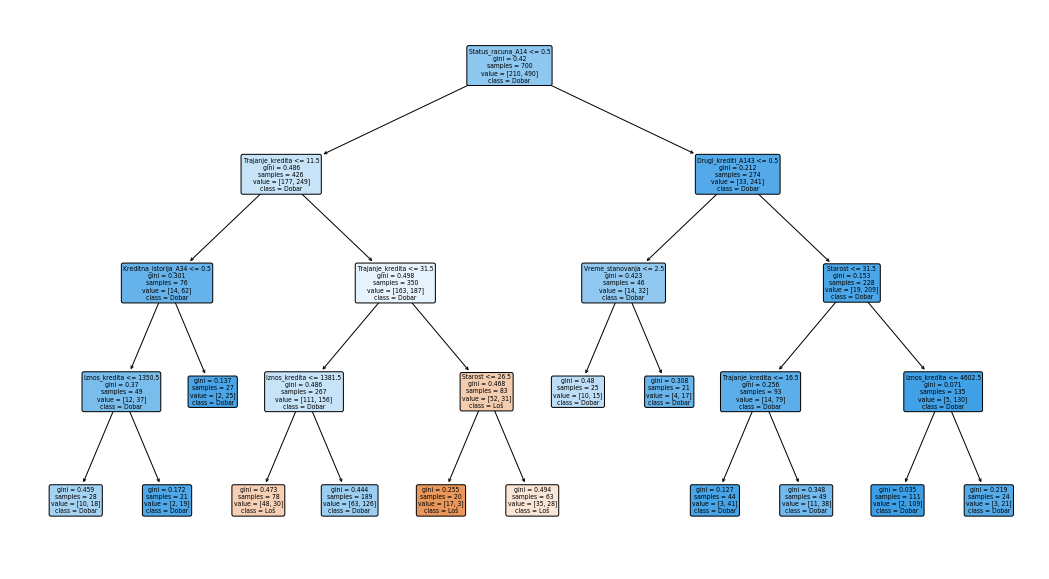

In [16]:
plt.figure(figsize=(18, 10))
plot_tree(doGini, 
        filled=True,
        feature_names=X_train.columns,
        class_names=["Loš", "Dobar"],
        rounded=True
)
plt.show()


## Hajde da proverimo znanje o stablima odlučivanja! 🧠

Odgovori na sledeća pitanja kako bi utvrdio svoje razumevanje algoritma, procesa grananja i ključnih hiperparametara.

:::{admonition} Kviz 1.
:class: hint 
1. Šta predstavlja primarnu funkciju algoritma stabla odlučivanja?  
a) Grupisanje sličnih instanci bez unapred definisanih oznaka (učenje bez nadzora)  
b) Kreiranje vizuelnih prikaza kompleksnih statističkih funkcija gustine  
c) Predviđanje vrednosti ciljne promenljive kroz seriju logičkih podela nad atributima  
d) Redukcija broja atributa radi lakše obrade podataka  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Predviđanje vrednosti ciljne promenljive kroz seriju logičkih podela nad atributima
```
:::

:::{admonition} Kviz 2.
:class: hint 
2. Kako se naziva čvor u strukturi stabla koji ne podleže daljem grananju i sadrži finalnu predikciju?  
a) korenski čvor   
b) unutrašnji čvor    
c) list   
d) grana  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) list
```
:::

:::{admonition} Kviz 3.
:class: hint 
3. Kako se naziva čvor u strukturi stabla koji ne podleže daljem grananju i sadrži finalnu predikciju?  
a) Standardna devijacija    
b) Srednja vrednost   
c) Entropija ili Gini indeks     
d) Varijansa    

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Entropija ili Gini indeks
```
:::

:::{admonition} Kviz 4.
:class: hint 
4. Na koji način prekomerna kompleksnost stabla utiče na njegovu sposobnost predviđanja nad novim podacima?  
a) Model gubi sposobnost predikcije trening podataka.   
b) Model postaje precizan i dostiže optimalan balans između pristrasnosti i varijanse.   
c) Model preterano detaljno mapira trening set, što rezultira fenomenom preprilagođavanja (overfitting).  
d) Kompleksnost strukture stabla nema uticaja na performanse modela.  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Model preterano detaljno mapira trening set, što rezultira fenomenom preprilagođavanja (overfitting).
```
:::

:::{admonition} Kviz 5.
:class: hint 
5. Koja od navedenih karakteristika NIJE svojstvena algoritmu stabla odlučivanja?

a) Sposobnost efikasnog modelovanja kompleksnih, nelinearnih zavisnosti među atributima.  
b) Mogućnost simultane obrade i kategoričkih i numeričkih tipova podataka.  
c) Visoka otpornost na overfitting bez podešavanja  
d) Visok stepen interpretabilnosti i jednostavnost grafičkog prikaza logike odlučivanja.  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Visoka otpornost na overfitting bez podešavanja
```
:::

:::{admonition} Kviz 6.
:class: hint 
6. Kako se interpretira pojam entropije unutar algoritma stabla odlučivanja?
 
a) Kao parametar koji definiše maksimalni broj listova.  
b) Kao ukupan broj atributa uključenih u proces podele podataka.  
c) Kao metrika pomešanosti podataka u čvoru.  
d) Kao maksimalnu dubinu stabla.  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Kao metrika pomešanosti podataka u čvoru.
```
:::

:::{admonition} Kviz 7.
:class: hint 
7. Koja od navedenih tvrdnji ispravno opisuje karakteristike stabla odlučivanja?
 
a) Entropija i Gini indeks uvek rezultuju identičnim numeričkim vrednostima pri svakoj evaluaciji podele.  
b) Stabla odlučivanja uvek bolje generalizuju od linearnih modela.  
c) Pojava preprilagođavanja se javlja kada stablo ima previše čvorova i duboku strukturu.  
d) Stabla odlučivanja ne mogu da rade sa nedostajućim vrednostima.  

```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Pojava preprilagođavanja se javlja kada stablo ima previše čvorova i duboku strukturu.
```
:::

:::{admonition} Kviz 8.
:class: hint 
8. Algoritam stabla odlučivanja se ubraja u kategoriju:  
 
a) Algoritama nenadgledanog učenja   
b) Algoritama pojačanog učenja   
c) Algoritama nadgledanog učenja   
d) Algoritama sklonih greškama u klasifikaciji sa velikim brojem klasa   


```{admonition} Odgovor:
:class: dropdown
```python
**Odgovor:** c) Algoritama nadgledanog učenja
```
:::

## Zadaci i problemi
<br>

:::{admonition} Zadatak 1 - Kreditni rizik
:class: tip 

Skup podatak neophodan za ovaj zadatak se nalazi na sledećem linku [https://drive.google.com/file/d/1AofWwPEAgZcC88ttyG81bBA0VhIXYrPr/view?]

Ovaj skup podataka predstavlja pojednostavljeni model procene kreditnog rizika fizičkih lica u bankarskom sektoru. Cilj je klasifikacija klijenata prema nivou rizičnosti na osnovu njihovih socio-ekonomskih karakteristika i kreditnog opterećenja.

Skup sadrži 120 opservacija, gde svaka opservacija predstavlja jednog klijenta. Podaci su sintetički generisani, ali su strukturirani tako da odražavaju realne odnose koji se uočavaju u praksi bankarskog odlučivanja.

*Struktura podataka*. U skupu se nalazi pet ulaznih promenljivih (features) i jedna ciljna promenljiva (target):
- `income` - Mesečni prihod klijenta (u evrima). Viši prihodi obično ukazuju na veću sposobnost otplate kredita.
- `age` - Starost klijenta (u godinama). Može imati indirektan uticaj kroz stabilnost prihoda i radni status.
- `loan_amount` - Iznos kredita koji klijent traži. Veći iznosi povećavaju potencijalni rizik.
- `employment_years` - Broj godina radnog iskustva. Veća stabilnost zaposlenja obično smanjuje kreditni rizik.
- `existing_loans `- Broj postojećih kredita. Veći broj zaduženja povećava finansijski pritisak.
- `credit_risk` - Kategorijalna promenljiva koja predstavlja nivo kreditnog rizika:
  - `low`
  - `medium`
  - `high`

Ekonomska interpretacija: Kreditni rizik je određen kombinacijom faktora koji odražavaju odnos između zaduženosti i sposobnosti otplate. Ključni odnos u ovom skupu je implicitno definisan kroz:
- odnos iznosa kredita i prihoda
- nivo postojećeg zaduženja
- stabilnost zaposlenja

Klijenti sa visokim odnosom duga i prihoda, većim brojem kredita i kraćim radnim stažom imaju veću verovatnoću da budu klasifikovani kao rizični.

*Tip problema*. Ovaj skup podataka predstavlja primer problema nadgledanog učenja:
- tip zadatka: klasifikacija
- broj klasa: 3 (low, medium, high)

priroda promenljivih: numeričke + jedna kategorijalna ciljna promenljiva

**Zahtevi:**
1. Učitaj skup podataka.
2. Istraži distribucije promenljivih i odnose između njih.
3. Podeli podatke na trening i test skup.
4. Izgradi model stabla odlučivanja.
5. Evaluiraj tačnost modela.
6. Interpretiraj koje promenljive najviše utiču na procenu rizika.
:::

:::{admonition} Zadatak 2 - Analiza potražnje proizvoda
:class: tip 

Skup podatak neophodan za ovaj zadatak se nalazi na sledećem linku [https://drive.google.com/file/d/1uozylpxsziVW_2_41lVPcI7OtvTsZYhI/view?usp=sharing]

Kompanija koja posluje na konkurentnom tržištu želi da bolje razume faktore koji utiču na potražnju za njenim proizvodima. U cilju unapređenja poslovne strategije, prikupljeni su podaci o karakteristikama proizvoda i njihovoj tržišnoj uspešnosti.

Za svaki proizvod poznati su podaci o ceni, ulaganjima u marketing, starosti proizvoda, broju konkurenata i oceni kvaliteta. Na osnovu ovih informacija, proizvod je klasifikovan u jednu od tri kategorije potražnje:
- `low`
- `medium`
- `high`

*Podaci*. Skup podataka sadrži sledeće promenljive:
- `price` – cena proizvoda
- `marketing_spend` – ulaganja u marketing
- `product_age` – starost proizvoda
- `competitors` – broj konkurenata
- `rating` – ocena proizvoda
- `demand_level` – nivo potražnje

Na osnovu datog skupa podataka:
1. Učitaj podatke i prikaži osnovne informacije o skupu podataka.
2. Podeli podatke na trening i test skup.
3. Izgradi Random Forest klasifikacioni model za predviđanje promenljive `demand_level`.
4. Izvrši predikciju nad test skupom.
5. Oceni model korišćenjem odgovarajućih metrika klasifikacije.
6. Analiziraj značaj promenljivih u modelu.
7. Interpretiraj dobijene rezultate u ekonomskom kontekstu.
8. Na osnovu analize, predloži konkretne mere za povećanje potražnje proizvoda.
:::

Literatura 

Hastie, Trevor; Tibshirani, Robert; Friedman, Jerome (2001). The Elements of Statistical Learning. Springer. pp. 269–272. ISBN 0-387-95284-5.